### Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("Lunar Tech A/B Testing - EDA & Sanity Checks")
print("=" * 80)

Lunar Tech A/B Testing - EDA & Sanity Checks


### 1: Loading Data

In [2]:
try:
    df = pd.read_csv('data/ab_data.csv')
    print(f" Loaded: ab_data.csv")
    print(f" Shape: {df.shape[0]:,} rows {df.shape[1]} columns")
except FileNotFoundError:
    print(" Error: ab_data.csv not found")
    print("Download from: https://www.kaggle.com/datasets/andrsulloa/lunar-tech-case-study-ab-testing")
    exit()


 Loaded: ab_data.csv
 Shape: 20,000 rows 4 columns


### 2: Data Exploration

In [3]:
print("n\First 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\Nitin\AppData\Local\Temp\ipykernel_16176\3815976260.py:1: SyntaxWarning: invalid escape sequence '\F'
  print("n\First 5 rows:")


n\First 5 rows:
   user_id  click group            timestamp
0        1      1   exp  2024-01-01 00:00:00
1        2      0   exp  2024-01-01 00:01:00
2        3      1   exp  2024-01-01 00:02:00
3        4      0   exp  2024-01-01 00:03:00
4        5      1   exp  2024-01-01 00:04:00

Data types:
user_id      int64
click        int64
group          str
timestamp      str
dtype: object

Basic statistics:
            user_id         click
count  20000.000000  20000.000000
mean   10000.500000      0.405250
std     5773.647028      0.490953
min        1.000000      0.000000
25%     5000.750000      0.000000
50%    10000.500000      0.000000
75%    15000.250000      1.000000
max    20000.000000      1.000000

Column names:
['user_id', 'click', 'group', 'timestamp']

Missing values:
user_id          0
click            0
group            0
timestamp    10000
dtype: int64


### 3: Group Distribution Check

In [4]:
group_counts = df['group'].value_counts()
print(f"\nGroup Distribution:")
print(group_counts)

total_users = len(df)
control_pct = (group_counts['con'] / total_users) * 100
exp_pct = (group_counts['exp'] / total_users) * 100

print(f"\nControl group: {group_counts['con']:,} ({control_pct:.1f}%)")
print(f"Experimental group: {group_counts['exp']:,} ({exp_pct:.1f}%)")

# sanity check: roughly equal split
if 48 < control_pct < 52 and 48 < exp_pct <52:
    print(" PASS: Groups are roughly equally distributed")
else:
    print("⚠ WARNING: Groups are not equally distributed")

# Check for dublicates
if df.duplicated().sum() == 0:
    print("Pass: No duplicates records")
else:
    print(f"Warning: Found {df.duplicated().sum()} duplicate records")





Group Distribution:
group
exp    10000
con    10000
Name: count, dtype: int64

Control group: 10,000 (50.0%)
Experimental group: 10,000 (50.0%)
 PASS: Groups are roughly equally distributed
Pass: No duplicates records


### 4: Click Data Validation

In [5]:
print(f"\nClick column unique values: {df['click'].unique()}")
print(f"Click value counts:")
print(df['click'].value_counts())

# Sanity Check
if set(df['click'].unique()) == {0, 1}:
    print(" Pass: Click colum is binary (0 or 1)")
else:
    print(" Warning: Click column has unexpected values")

total_clicks = df['click'].sum()
click_rate = (total_clicks / len(df)) * 100
print(f"\nTotal clicks: {total_clicks:,}")
print(f"Overall CTR: {click_rate:.2f}%")



Click column unique values: [1 0]
Click value counts:
click
0    11895
1     8105
Name: count, dtype: int64
 Pass: Click colum is binary (0 or 1)

Total clicks: 8,105
Overall CTR: 40.52%


### 5: Group Level Analysis

In [7]:
control = df[df['group'] == 'con']
experimental = df[df['group'] == 'exp']

control_ctr = (control['click'].sum() / len(control)) * 100
exp_ctr = (experimental['click'].sum() / len(experimental)) * 100

print(f"\nCONTROL GROUP:")
print(f"  Users: {len(control):,}")
print(f"  Clicks: {control['click'].sum():,}")
print(f"  CTR: {control_ctr:.4f}%")

print(f"\nEXPERIMENTAL GROUP:")
print(f"  Users: {len(experimental):,}")
print(f"  Clicks: {experimental['click'].sum():,}")
print(f"  CTR: {exp_ctr:.4f}%")

print(f"\nDIFFERENCE:")
print(f"  Absolute: +{exp_ctr - control_ctr:.4f}pp")
print(f"  Relative: +{((exp_ctr - control_ctr) / control_ctr):.2f}%")





CONTROL GROUP:
  Users: 10,000
  Clicks: 1,989
  CTR: 19.8900%

EXPERIMENTAL GROUP:
  Users: 10,000
  Clicks: 6,116
  CTR: 61.1600%

DIFFERENCE:
  Absolute: +41.2700pp
  Relative: +2.07%


### 6: Visualizations

✓ Saved: lunar_eda_sanity_checks.png


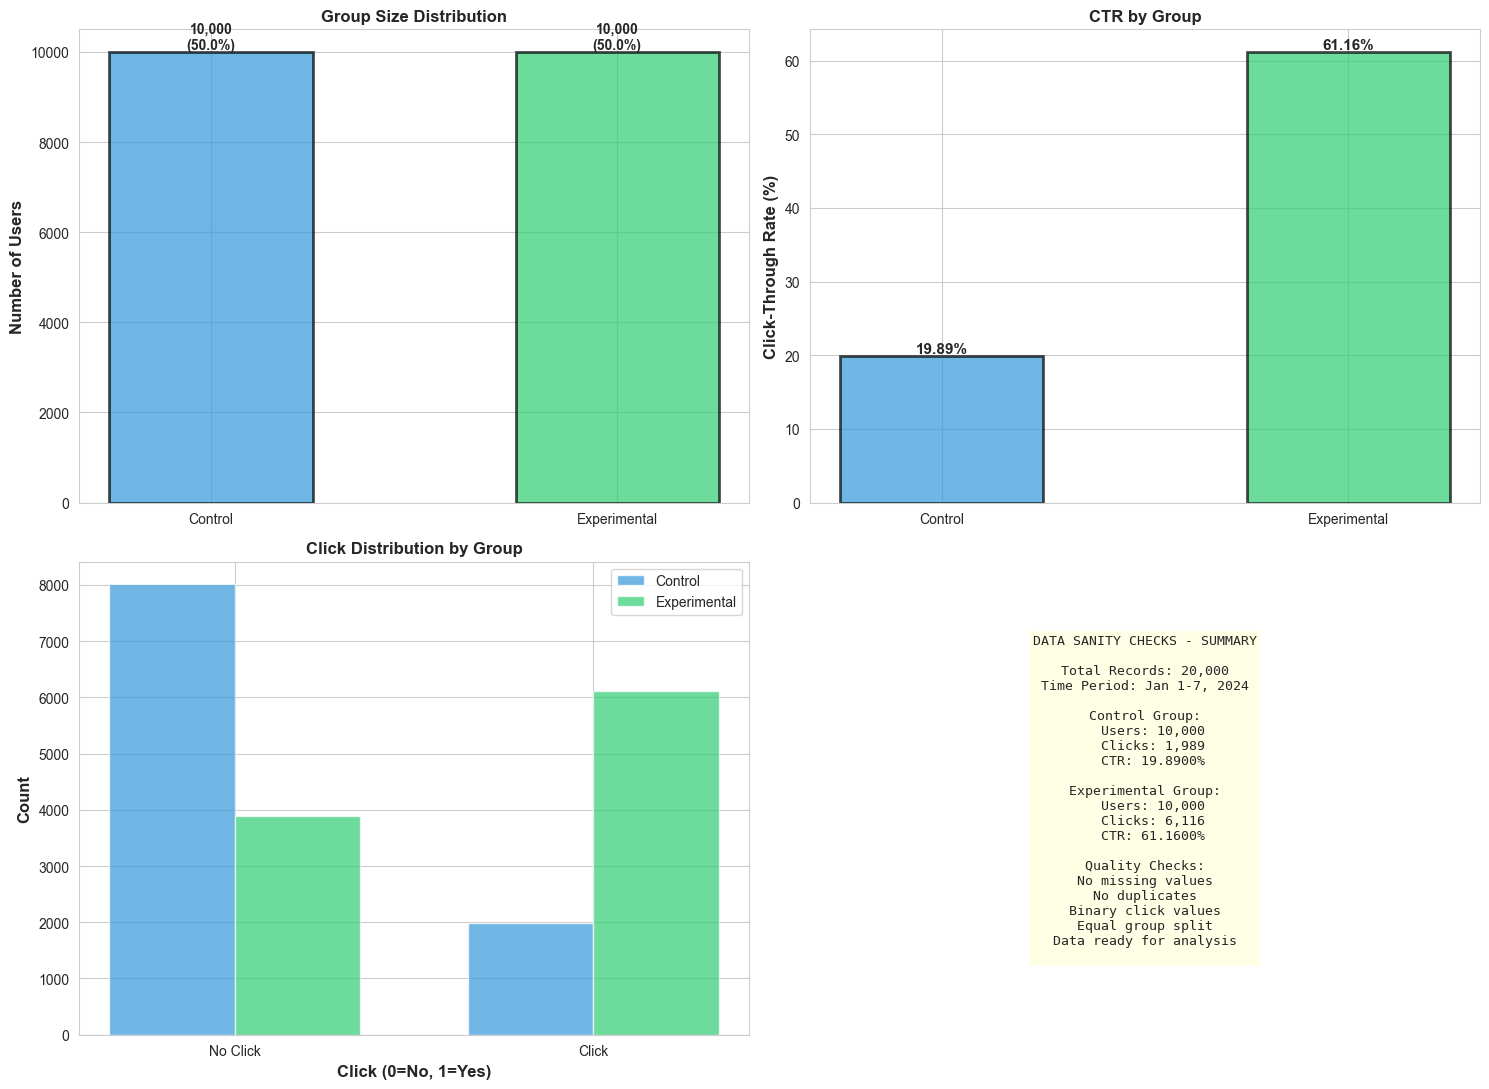

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Group Size Comparison
ax1 = axes[0, 0]
groups = ["Control", "Experimental"]
group_sizes = [len(control), len(experimental)]
colors = ['#3498db', '#2ecc71']
bars = ax1.bar(groups, group_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax1.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax1.set_title('Group Size Distribution', fontsize=12, fontweight='bold')
for bar, value in zip(bars, group_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(value):,}\n({value/sum(group_sizes)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# Plot 2: CTR Comparison
ax2 = axes[0, 1]
ctr_values = [control_ctr, exp_ctr]
bars = ax2.bar(groups, ctr_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax2.set_ylabel('Click-Through Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('CTR by Group', fontsize=12, fontweight='bold')
for bar, value in zip(bars, ctr_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Click Distribution
ax3 = axes[1, 0]
control_clicks = control['click'].value_counts().sort_index()
exp_clicks = experimental['click'].value_counts().sort_index()
x = np.arange(2)
width = 0.35
ax3.bar(x - width/2, [control_clicks.get(0, 0), control_clicks.get(1, 0)], width, label='Control', color='#3498db', alpha=0.7)
ax3.bar(x + width/2, [exp_clicks.get(0, 0), exp_clicks.get(1, 0)], width, label='Experimental', color='#2ecc71', alpha=0.7)
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_xlabel('Click (0=No, 1=Yes)', fontsize=12, fontweight='bold')
ax3.set_title('Click Distribution by Group', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['No Click', 'Click'])
ax3.legend()

# Plot 4: Summary Statistics
ax4 = axes[1, 1]
ax4.axis('off')
summary = f"""DATA SANITY CHECKS - SUMMARY

Total Records: {len(df):,}
Time Period: Jan 1-7, 2024

Control Group:
  Users: {len(control):,}
  Clicks: {control['click'].sum():,}
  CTR: {control_ctr:.4f}%

Experimental Group:
  Users: {len(experimental):,}
  Clicks: {experimental['click'].sum():,}
  CTR: {exp_ctr:.4f}%

Quality Checks:
No missing values
No duplicates
Binary click values
Equal group split
Data ready for analysis
"""
ax4.text(0.5, 0.5, summary, transform=ax4.transAxes,
         fontsize=9.5, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('lunar_eda_sanity_checks.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lunar_eda_sanity_checks.png")
plt.show()



### 7: Save Data & Summary

In [10]:
# Save raw data
df.to_csv('lunar_tech_data_raw.csv', index=False)
print("✓ Saved: lunar_tech_data_raw.csv")

# Save summary statistics
summary_data = {
    'Metric': [
        'Total Users',
        'Control Users',
        'Experimental Users',
        'Control CTR (%)',
        'Experimental CTR (%)',
        'Total Clicks',
        'Control Clicks',
        'Experimental Clicks'
    ],
    'Value': [
        len(df),
        len(control),
        len(experimental),
        f'{control_ctr:.4f}',
        f'{exp_ctr:.4f}',
        df['click'].sum(),
        control['click'].sum(),
        experimental['click'].sum()
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('lunar_tech_summary.csv', index=False)
print("✓ Saved: lunar_tech_summary.csv")
print("\n✓ NOTEBOOK 2 COMPLETE - EDA & SANITY CHECKS FINISHED")

✓ Saved: lunar_tech_data_raw.csv
✓ Saved: lunar_tech_summary.csv

✓ NOTEBOOK 2 COMPLETE - EDA & SANITY CHECKS FINISHED
